In [13]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version used to compile PyTorch:", torch.version.cuda)
print("Is CUDA available?", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Device name (if available):", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")


PyTorch version: 2.7.0+cpu
CUDA version used to compile PyTorch: None
Is CUDA available? False
CUDA device count: 0
Device name (if available): N/A


In [11]:
import torch
print(torch.version.cuda)  # Should print 12.1 or similar
print(torch.cuda.is_available())  # Should print True if everything is correct

None
False


In [16]:
import hiddenlayer as hl
import torch
model = torch.load("C:/Users/User/Documents/Sooth_Features_Extraction_plat/Outputs_CNNencdec_both_2025-0527-111352/best_flame_model.pth")
model_graph = hl.build_graph(model, torch.randn(1, 3, 224, 224))
model_graph.save("model_graph", format="png")

ModuleNotFoundError: No module named 'torch.utils.serialization'

In [9]:
import os

import torch

import numpy as np
import scipy.io as sio



class Config:
    
    def __init__(self):
        self.root_dir = 'C:/Users/User/Documents/GenerateData/GeneratedData'  # Path to your dataset
        self.global_img_min = min([
            sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].min() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #min image value in the dataset for normalization        
        self.global_img_max = max([
            sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].max() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #max image value in the dataset for normalization
          
        self.global_T_min = min([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["T"].min() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #min temp in the dataset for normalization         
        self.global_T_max = max([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["T"].max() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #max temp in the dataset for normalization

        self.global_fv_min = min([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].min() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #min Fv in the dataset for normalization 
        self.global_fv_max = max([
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].max() for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        ]) #max Fv in the dataset for normalization  
        # #find max Fv size in dir
        self.Fvmax_height = max(
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].shape[0]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.Fvmax_width = max(
            sio.loadmat(os.path.join(self.root_dir, d, "sootCalculation.mat"))["fv"].shape[1]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.Imagemax_height = max(
            (sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].shape[0]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d)))
        )
        self.Imagemax_width = max(
            (sio.loadmat(os.path.join(self.root_dir, d, "CFDImage.mat"))["CFDImage"].shape[1]
            for d in os.listdir(self.root_dir) if os.path.isdir(os.path.join(self.root_dir, d)))
        )       
if __name__ == "__main__":
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    #config
    config = Config()
    print("global_img_min:", config.global_img_min)
    print("global_img_max:", config.global_img_max)
    print("global_T_min:", config.global_T_min)
    print("global_T_max:", config.global_T_max)
    print("global_fv_min:", config.global_fv_min)
    print("global_fv_max:", config.global_fv_max)
    print("Fvmax_height:", config.Fvmax_height)
    print("Fvmax_width:", config.Fvmax_width)
    print("Imagemax_height:", config.Imagemax_height)
    print("Imagemax_width:", config.Imagemax_width)

global_img_min: 0.0
global_img_max: 19941.026744724255
global_T_min: 299.0
global_T_max: 2828.0
global_fv_min: 0.0
global_fv_max: 11.224797513519933
Fvmax_height: 808
Fvmax_width: 213
Imagemax_height: 808
Imagemax_width: 213


In [3]:
import os
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # for a progress bar
import shutil

def load_all_values(root_dir):
    all_values = []
    dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    out_dir = 'C:/Users/User/Documents/GenerateData__20000'
    num_mat = 0
    for d in tqdm(dirs, desc="Loading CFDImage values"):
        mat_path = os.path.join(root_dir, d, "CFDImage.mat")
        dir_path = os.path.join(root_dir, d)
        if os.path.exists(mat_path):
            data = sio.loadmat(mat_path)["CFDImage"]
            move_flag = False
            #check if there is a value larger than 255 or smaller than 0
            if np.any(data > 15000):
                num_mat += 1
                # print(f"Warning: {np.sum(data > 20000)} Values out of range > 20000 in {mat_path}")
                move_flag = True
            if np.any(data < 0):
                # print(f"Warning: {np.sum(data < 0)} Values out of range < 0 in {mat_path}")
                move_flag = True
            # if move_flag:
            #     shutil.move(dir_path, os.path.join(out_dir, d))
            #     print(f"Moved {dir_path} to {os.path.join(out_dir, d)}")
            #     continue
            all_values.append(data.flatten())

    return np.concatenate(all_values), num_mat

# Set your directory
root_dir = 'C:/Users/User/Documents/GenerateData/GeneratedData'

# Load all values
all_data, num = load_all_values(root_dir)
# print(f"min value: {np.min(all_data)}")
# print(f"max value: {np.max(all_data)}")
# print(f"number of negative values: {np.sum(all_data < 0)}")
# print(f"number of values larger than 4049: {np.sum(all_data > 4049)}")
print(f"number of CFDImage.mat files with values larger than 15000: {num}")
# print(f"~~~ total number of values: {len(all_data)}")

# # Plot histogram
# plt.figure(figsize=(10, 6))
# plt.hist(all_data, bins=1000, color='skyblue', edgecolor='black', density=True)
# plt.title("Histogram of CFDImage Values")
# plt.xlabel("Value")
# plt.ylabel("Frequency")
# plt.xlim([-1000, 20000])  # Adjust based on your data range
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Loading CFDImage values: 100%|██████████| 11868/11868 [01:25<00:00, 138.04it/s]


number of CFDImage.mat files with values larger than 15000: 136


In [ ]:
#####This script checks for CFDImage.mat files in a directory and moves folders with certain data features
# 

import os
import scipy.io as sio
import numpy as np
from tqdm import tqdm  # for a progress bar
import shutil

root_dir = 'C:/Users/User/Documents/GenerateData/GeneratedData'
dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
out_dir = 'C:/Users/User/Documents/GenerateData__20000'
    
for d in tqdm(dirs, desc="Loading CFDImage values"):
    mat_path = os.path.join(root_dir, d, "CFDImage.mat")
    dir_path = os.path.join(root_dir, d)
    if os.path.exists(mat_path):
        data = sio.loadmat(mat_path)["CFDImage"]
        move_flag = False
        #check if there is a value larger than 255 or smaller than 0
        if np.any(data > 20000):
            # print(f"Warning: {np.sum(data > 20000)} Values out of range > 20000 in {mat_path}")
            move_flag = True
        if np.any(data < 0):
            # print(f"Warning: {np.sum(data < 0)} Values out of range < 0 in {mat_path}")
            move_flag = True
        if move_flag:
            shutil.move(dir_path, os.path.join(out_dir, d))
            print(f"Moved {dir_path} to {os.path.join(out_dir, d)}")
            

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4663.357].


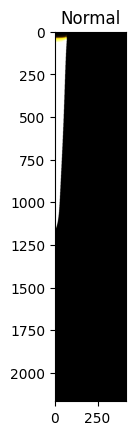

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..4663.357].


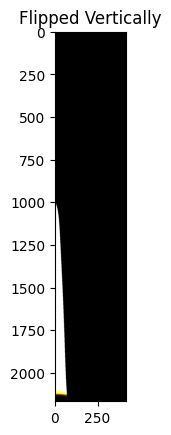

In [21]:
#check if need to flip arrays
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import os
from PIL import Image

# Load from .mat file
cfd_path = os.path.join('C:/Users/User/Documents/GenerateData/moresamples/00', "CFDImage.mat")
# cfd_path = os.path.join('C:/Users/User/Documents/GenerateData/GeneratedData_SingleTest/1', "CFDImage.mat")
# cfd_path = os.path.join('C:/Users/User/Documents/GenerateData/GeneratedData/9149', "CFDImage.mat")
cfd_mat = loadmat(cfd_path)
rgb = cfd_mat["CFDImage"].astype(np.float32)


# Try normal display
plt.imshow(rgb)
plt.title('Normal')
plt.show()

#display this way
image_array = rgb
image_array = image_array / np.max(image_array)
image_uint8 = (image_array * 255).astype(np.uint8)
# Convert to PIL image and save
image = Image.fromarray(image_uint8).convert("RGB")
image.show()
image.save(os.path.join('C:/Users/User/Documents/GenerateData/moresamples', 'CFDImage.jpg'))
# Try flipped vertically
plt.imshow(np.flipud(rgb))
plt.title('Flipped Vertically')
plt.show()

